# **Distribucion del dinero**


*   Sin inflación
*   Con número de agentes constante
*   No inyectamos dinero al sistema
* Sin deuda





In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
#Número de agentes
N = 100_000
#Dinero inicial
m_0 = 100
#Vector de agentes
M = np.ones(N)*m_0
#Cantidad maxima por intercambio
M_max = 100

In [ ]:
#Seleccionar dos agentes
def asig():
  count = 0
  while count == 0:
    x = np.random.randint(0,N,2)
    if x[0] != x[1]:
      count = 1
  return x

In [ ]:
count2 = 0 #contador de simulaciones
# Interacción entre agentes
while count2 < 1e6:
  i,j = asig()
  delm = np.random.random()*M_max
  if M[j] > delm:
    M[i] += delm
    M[j] -= delm
    count2 += 1


In [ ]:
#Guardar datos del vector de agentes en un archivo
#np.savetxt('dinero6.txt', M, fmt='%.6f')

# Datos generados

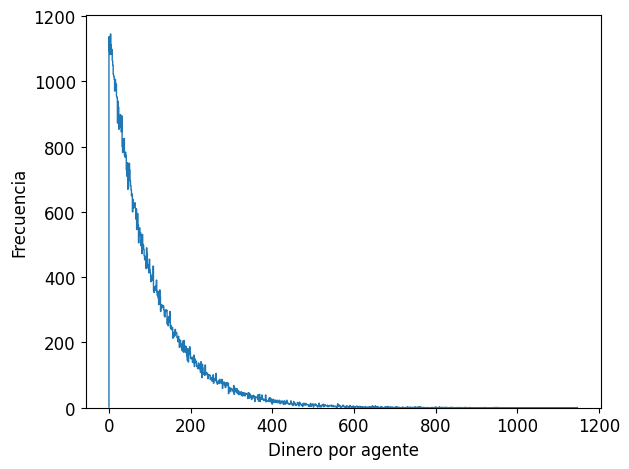

In [ ]:
#Obtener datos de las frecuencias
datos = pd.read_csv("Dinero_sindeuda_10_9_simulaciones.txt", header=None)
# Crear histograma
plt.hist(datos, bins=1000, histtype='step')
plt.xlabel('Dinero por agente', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.savefig("histograma1.jpg", dpi=300)
plt.show()


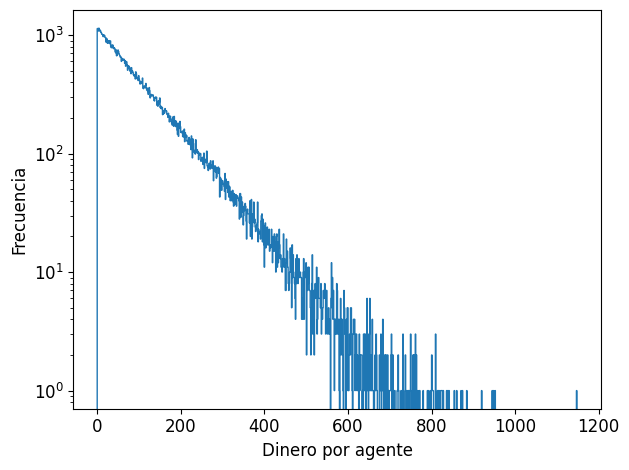

In [ ]:
# Crear histograma con escala logaritmica en las frecuencias
plt.hist(datos, bins=1000, histtype='step', log=True)
plt.xlabel('Dinero por agente', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.savefig("histograma2.jpg", dpi=300)
plt.show()

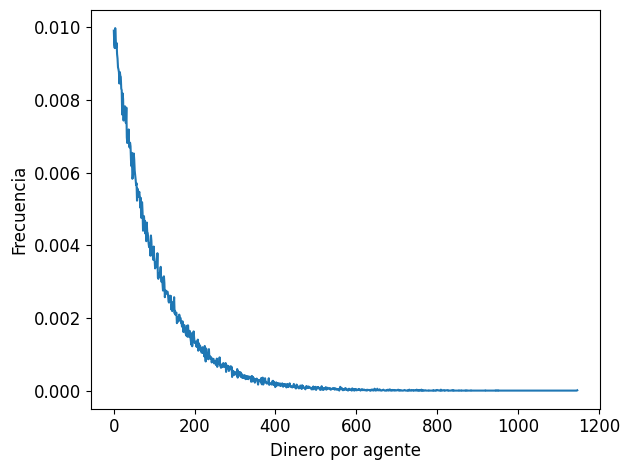

1.0000000000000002


In [ ]:
#Normalizar el histograma
hist, bin_edges = np.histogram(datos, bins=1000)
dx = bin_edges[1] - bin_edges[0]
histnorm = hist / np.sum(hist * dx)
bins = bin_edges[:-1]
plt.plot(bins, histnorm)
plt.xlabel('Dinero por agente', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.savefig("histonorm.jpg", dpi=300)
plt.show()

#Comprobar la normalizacion
print(np.sum(histnorm*dx))


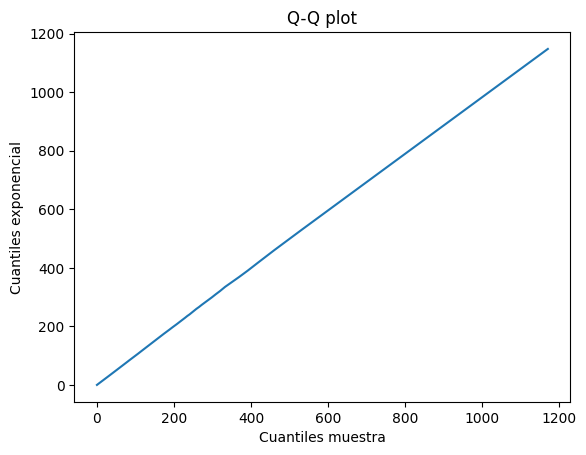

100000

In [ ]:
#Q-Q plot
#Comparando los cuantiles de nuestra muestra y una muestra de una distribucion exponencial
N_1 = np.random.exponential(100,100_000)
N_2 = datos
QN1 = np.quantile(N_1, np.linspace(0,1,200))
QN2 = np.quantile(N_2, np.linspace(0,1,200))

plt.plot(QN1, QN2)
plt.title('Q-Q plot')
plt.xlabel('Cuantiles muestra')
plt.ylabel('Cuantiles exponencial')
plt.show()

len(datos)

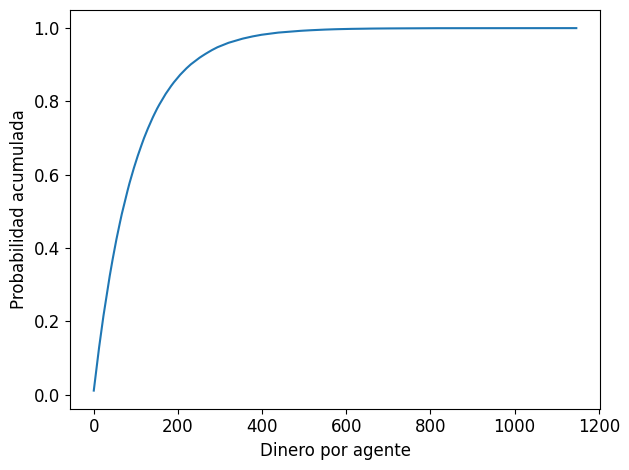

In [ ]:
#Grafica de la Probabilidad acumulada
yF = np.cumsum(histnorm*dx)
plt.plot(bins, yF)
plt.xlabel('Dinero por agente', fontsize=12)
plt.ylabel('Probabilidad acumulada', fontsize=12)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.savefig("probacu.jpg", dpi=300)
plt.show()

In [ ]:
#Prueba de Kolmogorov-Smirnov
from scipy import stats
from scipy.stats import kstest
from scipy.stats import ks_2samp

#Muestra vs Distribucion
stat, p_value = kstest(datos,'expon', args=(0, 100))


print("Estadístico KS:", stat)
print("p-valor:", p_value)

alpha = 0.05
if p_value < alpha:
    print("\nRechazamos la hipótesis nula. Los datos NO parecen seguir una distribución exponencial.")
else:
    print("\nNo podemos rechazar la hipótesis nula. Los datos podrían provenir de una distribución exponencial.")


Estadístico KS: [0.00150143]
p-valor: [0.9775809]

No podemos rechazar la hipótesis nula. Los datos podrían provenir de una distribución exponencial.


In [ ]:
#Muestra vs Muestra
y = np.random.exponential(100,10_000_000)
arr = np.asarray(datos).ravel()

stat, p_value = ks_2samp(arr, y)
print("\nEstadístico KS:", stat)
print("p-valor:", p_value)


Estadístico KS: 0.001684999999999992
p-valor: 0.9408376819538011


/tmp/ipython-input-3934928483.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  _, p_values[i]= kstest(datos_n,'expon', args=(0, float(1/a_vector[i])))


El valor de a que maximiza el p-valor es 0.01000502512562814


<Figure size 640x480 with 0 Axes>

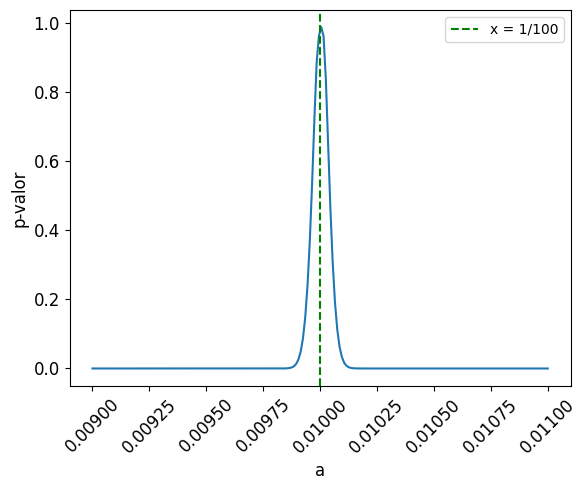

In [ ]:
#Grafica del p-valor vs. a
datos_n = np.asarray(datos) #convertir el dataframa a un arreglo numpy
a_vector = np.linspace(0.01-0.001,0.01+0.001,200)
p_values = np.zeros(len(a_vector))
plt.figure()
for i in range(len(a_vector)):
    _, p_values[i]= kstest(datos_n,'expon', args=(0, float(1/a_vector[i])))


max_p_index = np.argmax(p_values)  # índice del p-valor máximo
best_a = a_vector[max_p_index]     # valor de a correspondiente
max_p = p_values[max_p_index]
print("El valor de a que maximiza el p-valor es " + str(best_a))

plt.figure(figsize=(6,5))
plt.plot(a_vector, p_values,)
plt.axvline(x=0.01, color='g', linestyle='--', label='x = 1/100')
plt.xlabel('a', fontsize = 12)
plt.ylabel('p-valor', fontsize = 12)
plt.tick_params(axis='both', labelsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.savefig("pvalores.jpg", dpi=300)

plt.show()


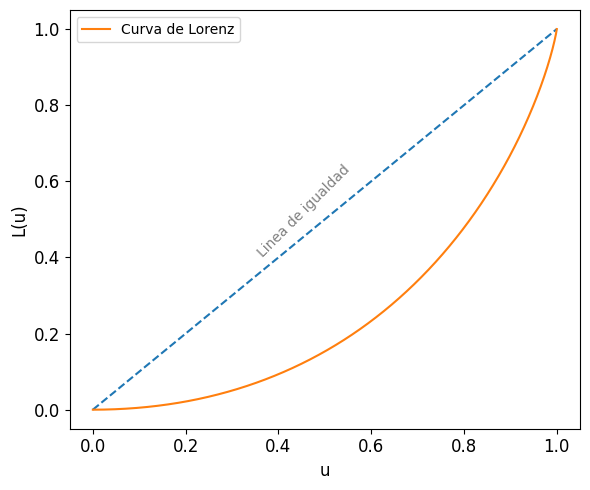

In [ ]:
# Grafica de la curva de Lorentz
def Lorentz(array):
    dinero = np.asarray(array, dtype=np.float64)
    n = array.shape[0] #número de agentes
    M_s = np.sort(dinero) #ordenamos las cantidades de dinero por agente
    y = np.cumsum(M_s)/(n*100) #obtenemos la porcion de dinero acumulado
    x = np.linspace(0,1,n)
    return x,y

#Grafica de la curva de Lorentz para nuestra muestra y grafica de la linea de igualdad
plt.figure(figsize=(6,5))
x_1 = np.linspace(0,1,100)
plt.plot(x_1,x_1, '--')
x,y= Lorentz(datos.iloc[:,0].to_numpy())
plt.plot(x,y, label = 'Curva de Lorenz')
x_pos = 0.35
y_pos = x_pos + 0.05

plt.text(x_pos, y_pos, 'Linea de igualdad', rotation=45, color='gray', fontsize=10)

plt.xlabel('u', fontsize = 12)
plt.ylabel('L(u)',  fontsize = 12)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.legend()
plt.savefig("lorenz.jpg", dpi=300)
plt.show()



In [ ]:
#Funcion que aplica una integral de Riemann
def integral(x,y):
    total = 0
    for i in range(len(x)-1):
        total += (x[i+1]-x[i])*(y[i+1])
    return total

#Calculo del indice de Gini para una muestra
G = 1 - 2*integral(x,y)
print("El indice de Gini es " + str(G))

El indice de Gini es 0.500235490869311


In [ ]:
#Promedio y desviacion estandar del indice de Gini
#Obtener datos de las frecuencias de 100 simulaciones
simulaciones = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/Simulacion (Jhony)/Dinero_100_simulaciones.txt",
    header=None, delim_whitespace=True)
filas, columnas = simulaciones.shape #100_000 x 100

#Calculamos el indice de Gini para las 100 simulaciones
G_vector = np.zeros(columnas)
for i in range(columnas):
    x, y = Lorentz(simulaciones.iloc[:, i].to_numpy())

    G_vector[i] = 1 - 2*integral(x,y)

#Promedio y desviacion estandar
promedio_gini = np.mean(G_vector)
desviacion_gini = np.std(G_vector)

print(f"Promedio del índice de Gini: {promedio_gini}")
print(f"Desviación estándar del índice de Gini: {desviacion_gini}")

/tmp/ipython-input-3734323917.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  simulaciones = pd.read_csv(


Promedio del índice de Gini: 0.4999811119854625
Desviación estándar del índice de Gini: 0.0009006971384543083


/tmp/ipython-input-35056165.py:3: RuntimeWarning: divide by zero encountered in log
  S = 1 + np.log(m_0)


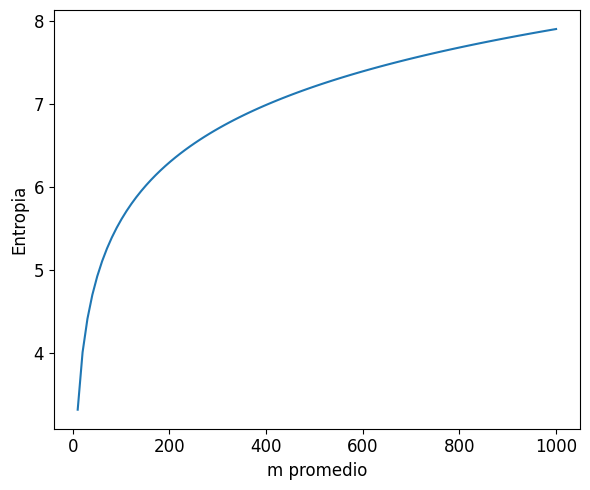

In [ ]:
#Entropia
m_0 = np.linspace(0,1000,100)
S = 1 + np.log(m_0)
plt.figure(figsize=(6,5))
plt.plot(m_0,S)
plt.ylabel('Entropia', fontsize = 12)
plt.xlabel('m promedio', fontsize = 12)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.savefig("entropia.jpg", dpi=300)
plt.show()
print

# Datos profesor

In [ ]:
#Leer los datos
datos = open("/content/drive/MyDrive/Colab Notebooks/Simulacion (Jhony)/data.txt")
xd = []
yd = []
for line in datos:
  x = line.split()
  x_1 = float(x[0])
  x_2 = float(x[1])
  xd.append(x_1)
  yd.append(x_2)

/tmp/ipython-input-402985920.py:2: RuntimeWarning: divide by zero encountered in log
  yd_log = np.log(yd)


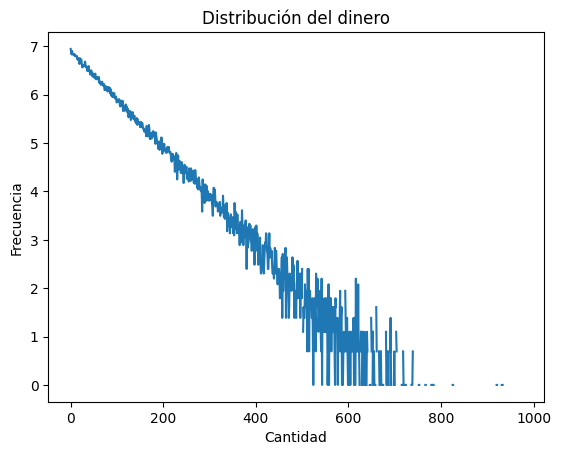

In [ ]:
#Graficar histograma en escala logaritmica
yd_log = np.log(yd)
plt.plot(xd, yd_log)
#plt.yscale('log')
plt.title('Distribución del dinero')
plt.xlabel('Cantidad')
plt.ylabel('Frecuencia')
plt.show()

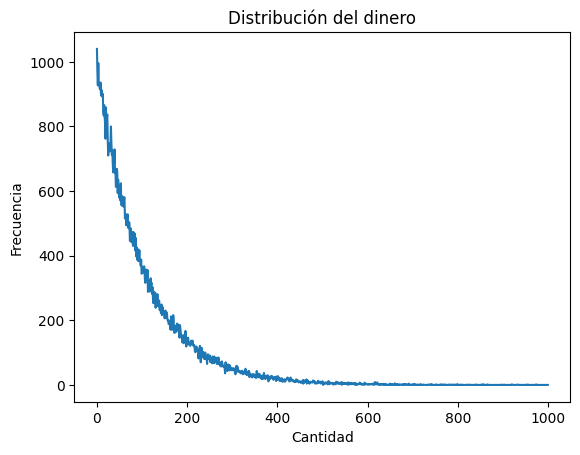

In [ ]:
#Graficar histograma
plt.plot(xd, yd)
plt.title('Distribución del dinero')
plt.xlabel('Cantidad')
plt.ylabel('Frecuencia')
plt.show()

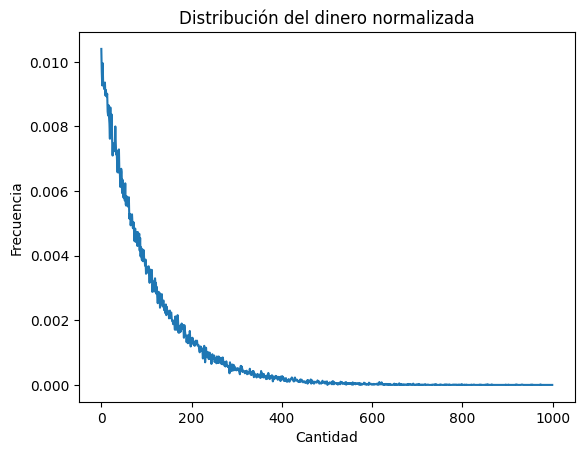

np.float64(1.0)

In [ ]:
#Calcular la constante de normalizacion
#En este caso delta(x) = 1
A = np.sum(yd)
#Graficar
plt.title('Distribución del dinero normalizada')
plt.xlabel('Cantidad')
plt.ylabel('Frecuencia')
ydnorm = yd/A
plt.plot(xd, ydnorm)
plt.show()
#Comprobar normalización
B = np.sum(yd/A)
B

/tmp/ipython-input-1022967896.py:9: RuntimeWarning: divide by zero encountered in log
  ydnorm_log = np.log(ydnorm)


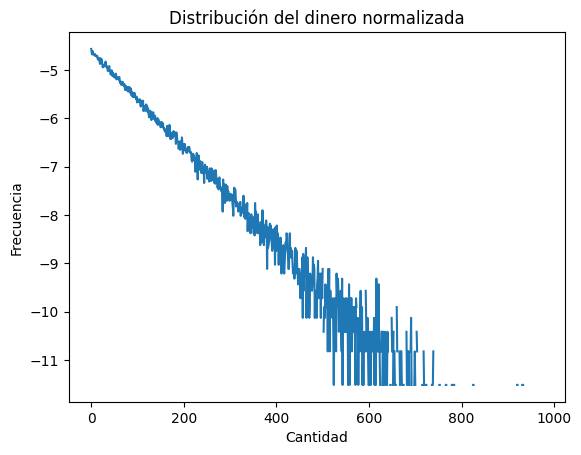

1000


In [ ]:
#Calcular la constante de normalizacion
#En este caso delta(x) = 1
A = np.sum(yd)
#Graficar
plt.title('Distribución del dinero normalizada')
plt.xlabel('Cantidad')
plt.ylabel('Frecuencia')
ydnorm = yd/A
ydnorm_log = np.log(ydnorm)
plt.plot(xd, ydnorm_log)
plt.show()
#Comprobar normalización
B = np.sum(yd/A)
B


/tmp/ipython-input-88886708.py:6: RuntimeWarning: divide by zero encountered in log
  plt.plot(xd, np.log(ydnorm))


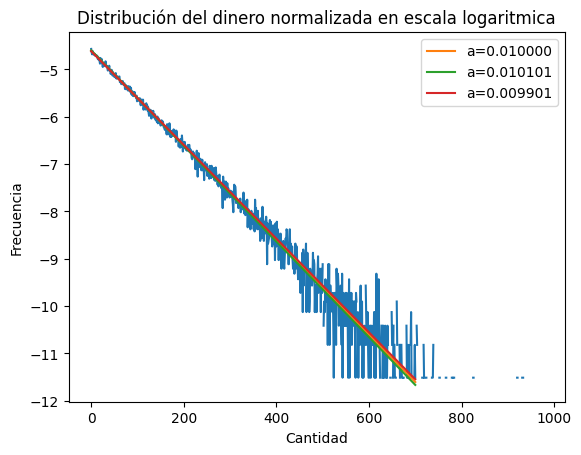

In [ ]:
#Graficar el histograma contra muestras de una distribucion exponencial
xfit = np.linspace(0, 700, 1000)
a_array = np.array((1.0/100.0, 1.0/99.0, 1.0/101.0))

plt.figure()
plt.plot(xd, np.log(ydnorm))
for a in a_array:
    yfit = a * np.exp(-a * xfit)
    yfit_log = np.log(yfit)
    plt.plot(xfit, yfit_log, label=f"a={a:.6f}")


plt.legend()
plt.title('Distribución del dinero normalizada en escala logaritmica')
plt.xlabel('Cantidad')
plt.ylabel('Frecuencia')
plt.show()



In [ ]:
#Q-Q plot
#Comparando los cuantiles de una distribucion gaussiana y una exponencial.
N_1 = np.random.exponential(1,1000000)
N_2 = np.random.normal(0,1,1000000)

QN1 = np.quantile(N_1, np.linspace(0,1,100))
QN2 = np.quantile(N_2, np.linspace(0,1,100))
plt.title('Q-Q plot normal vs. exponencial')
plt.xlabel('Exponencial')
plt.ylabel('Gaussiana')
plt.plot(QN1, QN2)
plt.show()

In [ ]:
#Grafica de la Probabilidad acumulada
yF = np.cumsum(ydnorm)
plt.plot(xd, yF)
plt.title('Probabilidad acumulada')
plt.xlabel('Cantidad')
plt.ylabel('Probabilidad')
plt.show()

/tmp/ipython-input-1417919951.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_B = np.trapz(L, U)


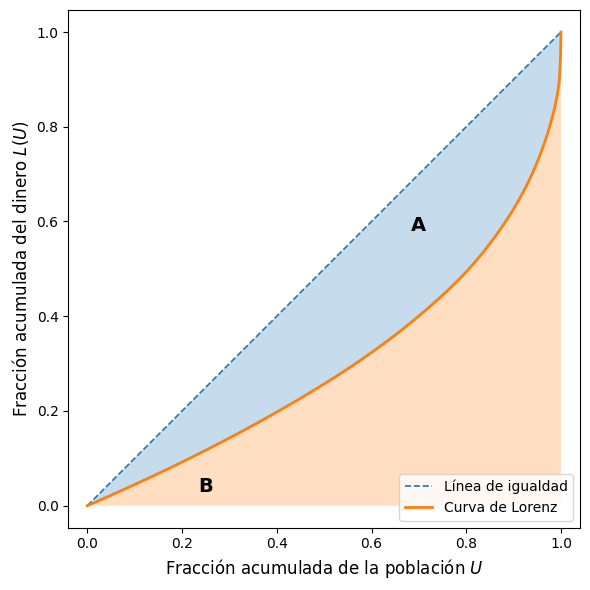

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Generar distribución desigual (Pareto) y calcular Lorenz
N = 1000
vals = np.random.pareto(a=1.8, size=N) + 1.0
vals.sort()
cum = np.cumsum(vals)
U = np.concatenate(([0.0], np.arange(1, N+1)/N))
L = np.concatenate(([0.0], cum / cum[-1]))

# Área bajo la curva B y área entre igualdad y Lorenz A
area_B = np.trapz(L, U)
area_A = 0.5 - area_B

# Crear figura
plt.figure(figsize=(6,6))

# Línea de igualdad y curva de Lorenz
plt.plot(U, U, linestyle='--', linewidth=1.2, label='Línea de igualdad')
plt.plot(U, L, linewidth=2, label='Curva de Lorenz')

# Sombrear áreas
plt.fill_between(U, L, U, where=(U>=L), alpha=0.25)
plt.fill_between(U, 0, L, alpha=0.25)

# Etiquetas A y B
u_A = 0.7
idx_A = np.searchsorted(U, u_A)
y_A = 0.5*(L[idx_A] + U[idx_A])
plt.text(u_A, y_A + 0.03, 'A', fontsize=14, fontweight='bold', ha='center')

u_B = 0.25
idx_B = np.searchsorted(U, u_B)
y_B = 0.5*L[idx_B]
plt.text(u_B, y_B - 0.03, 'B', fontsize=14, fontweight='bold', ha='center')

# Etiquetas de ejes y leyenda
plt.xlabel('Fracción acumulada de la población $U$', fontsize=12)
plt.ylabel('Fracción acumulada del dinero $L(U)$', fontsize=12)
plt.legend(loc='lower right')

# Escala igual y layout
plt.axis('equal')  # 🔹 igual escala en ambos ejes
plt.tight_layout()

# Guardar figura
plt.savefig("curva11.jpg", dpi=300)
plt.show()

